In [35]:
from mc_experiment import (
    make_seed_counter,
    next_seed,
    standardize_innovations,
    summarize_reference_experiment,
    summarize_mle_augmentation_experiment,
    augmented_config_path,
    size_adjusted_power_comparison,
)

from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.bayesian import make_prior

from numpy import log
import numpy as np

from scipy.stats import chi2, gaussian_kde, norm

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import cProfile

import contextlib
import io
STDOUT_VOID = lambda: contextlib.redirect_stdout(io.StringIO())

_KNOWN_R = True
_AUGMENTED_PARAM = 'x_coef'
_AUGMENTED_EQUATION = 'Rate'
_AUGMENTED_CONFIG = augmented_config_path(_AUGMENTED_EQUATION)
_MEAS_ERR_SCALE = 0.10
_MC_SAMPLES = 1000
_MC_ALPHA = 0.05
_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)


In [36]:
# Load reference model
parser = ModelParser("../../MODELS/misspec_test/reference.yaml")
config, kalman = parser.get_all()
solver = DSGESolver(config, kalman)

comp = solver.compile(
    n_state=3,
    n_exog=3,
)
sol = solver.solve(
    comp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

print("Transition matrix:\n", sol.A.round(3), "\n")
print("Shock Loadings:\n", sol.B.round(3))

Transition matrix:
 [[ 0.83   0.     0.     0.     0.   ]
 [ 0.     0.85   0.     0.     0.   ]
 [ 0.288 -0.047  0.28   0.     0.   ]
 [ 0.892  0.708 -1.711  0.     0.   ]
 [ 0.7   -0.115 -1.363  0.     0.   ]] 

Shock Loadings:
 [[ 1.     0.     0.   ]
 [ 0.     1.     0.   ]
 [ 0.     0.     1.   ]
 [ 3.193  0.493 -6.107]
 [ 2.531 -0.406 -4.864]]


In [37]:
# Load Misspecified DGP
parser_dgp = ModelParser("../../MODELS/misspec_test/misspec.yaml")
config_dgp, kalman_dgp = parser_dgp.get_all()
solver_dgp = DSGESolver(config_dgp, kalman_dgp)
comp_dgp = solver_dgp.compile(
    n_state=3,
    n_exog=3,
)
sol_dgp = solver_dgp.solve(
    comp_dgp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [38]:
# Large sample simulations used to approximate measurement-noise variances
_large_sample_seed_counter = make_seed_counter(start=100_000)
shocks_large = {
    "g,z": Shock(10_000, "norm", multivar=True, seed=next_seed(_large_sample_seed_counter)).shock_generator(),
    "r": Shock(10_000, "norm", multivar=False, seed=next_seed(_large_sample_seed_counter)).shock_generator(),
}

sim1 = sol_dgp.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)

sim2 = sol.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)

In [39]:
T = 200
_plot_seed_counter = make_seed_counter(start=2_000_000)

err_var = np.var(np.column_stack([sim1["OutGap"], sim1["Infl"], sim1["Rate"]]), axis=0)
mc_reference = summarize_reference_experiment(
    sol,
    sol_dgp,
    T=T,
    err_var=err_var,
    meas_err_scale=_MEAS_ERR_SCALE,
    mc_samples=_MC_SAMPLES,
    known_r=_KNOWN_R,
    alpha=_MC_ALPHA,
)

rep_ref = mc_reference["representative"]
sim_dgp = rep_ref.sim_dgp
obs = rep_ref.obs
kf = rep_ref.kf
std_innov = rep_ref.std_innov
err_scale = rep_ref.err_scale
N, n_obs = kf.innov.shape

_measurement_order = {"OutGap": 0, "Infl": 1, "Rate": 2}
_predictor_order = {"Pi": 0, "x": 1, "r": 2}

def _sort_summary(df):
    out = df.copy()
    if "measurement" in out.columns:
        out["measurement_order"] = out["measurement"].map(_measurement_order)
    if "predictor" in out.columns:
        out["predictor_order"] = out["predictor"].map(_predictor_order)
    if "target" in out.columns:
        out["target_order"] = out["target"].map(_predictor_order)
    if "regressor" in out.columns:
        out["regressor_order"] = out["regressor"].map(_predictor_order)
    sort_cols = [
        col
        for col in ["measurement_order", "target_order", "predictor_order", "regressor_order"]
        if col in out.columns
    ]
    if sort_cols:
        out = out.sort_values(sort_cols)
    return out.drop(columns=[col for col in ["measurement_order", "target_order", "predictor_order", "regressor_order"] if col in out.columns])

sim_ref = sol.sim(
    T=T,
    shocks={
        "g,z": Shock(T, "norm", multivar=True, seed=next_seed(_plot_seed_counter)).shock_generator(),
        "r": Shock(T, "norm", multivar=False, seed=next_seed(_plot_seed_counter)).shock_generator(),
    },
    observables=True,
)
ref = np.column_stack([sim_ref["OutGap"], sim_ref["Infl"], sim_ref["Rate"]])[1:, :]

obs_dgp = np.column_stack([sim1["OutGap"], sim1["Infl"], sim1["Rate"]])[1:, :]
if np.any(err_scale != 0.0):
    _plot_rng = np.random.default_rng(next_seed(_plot_seed_counter))
    obs_dgp = obs_dgp + _plot_rng.normal(scale=np.sqrt(err_scale), size=obs_dgp.shape)

In [40]:
print(f"Known R assumption: {_KNOWN_R}")
print(f"Augmented measurement equation: {_AUGMENTED_EQUATION}")
print(f"Augmented coefficient: {_AUGMENTED_PARAM}")
print(f"Monte Carlo replications: {_MC_SAMPLES}")
print("Noise Covariance:\n", np.diag(err_scale).round(3))


Known R assumption: True
Monte Carlo replications: 1000
Noise Covariance:
 [[1.208 0.    0.   ]
 [0.    1.679 0.   ]
 [0.    0.    0.078]]


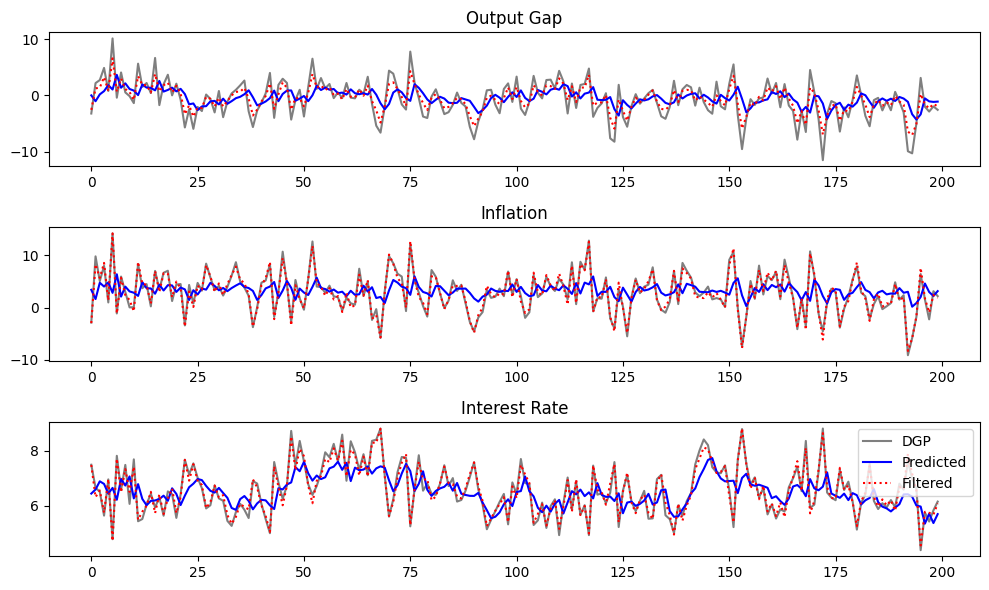

In [41]:
# Plot filter outputs for the representative draw
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.5)
ax[0].plot(range(T), kf.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.5)
ax[1].plot(range(T), kf.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1].set_title("Inflation")

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.5)
ax[2].plot(range(T), kf.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

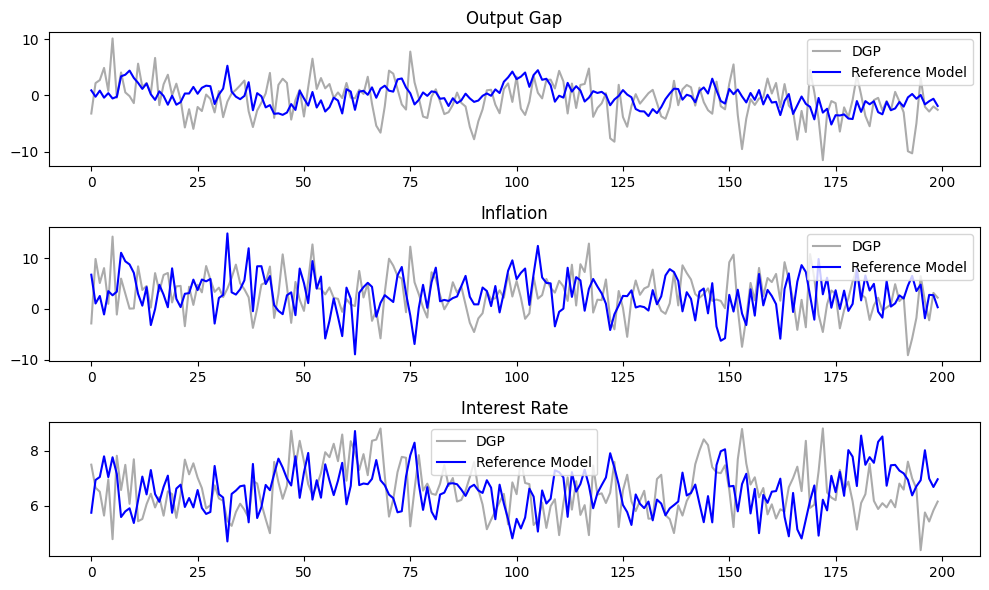

In [42]:
# Simulation against DGP for the representative draw
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), ref[:, 0], label="Reference Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), ref[:, 1], label="Reference Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), ref[:, 2], label="Reference Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

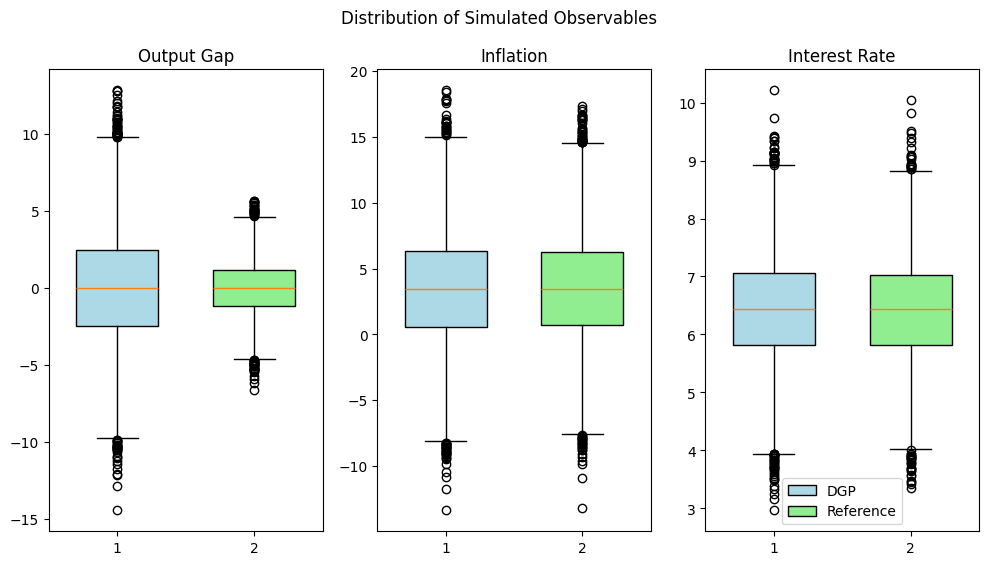

In [43]:
fig, ax = plt.subplots(1, 3, figsize=_FIGSIZE_2D)

plt.suptitle("Distribution of Simulated Observables")

ax[0].boxplot(obs_dgp[:, 0], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[0].boxplot(sim2["OutGap"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[0].set_title("Output Gap")

ax[1].boxplot(obs_dgp[:, 1], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[1].boxplot(sim2["Infl"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[1].set_title("Inflation")

ax[2].boxplot(obs_dgp[:, 2], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[2].boxplot(sim2["Rate"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[2].set_title("Interest Rate")
ax[2].legend()

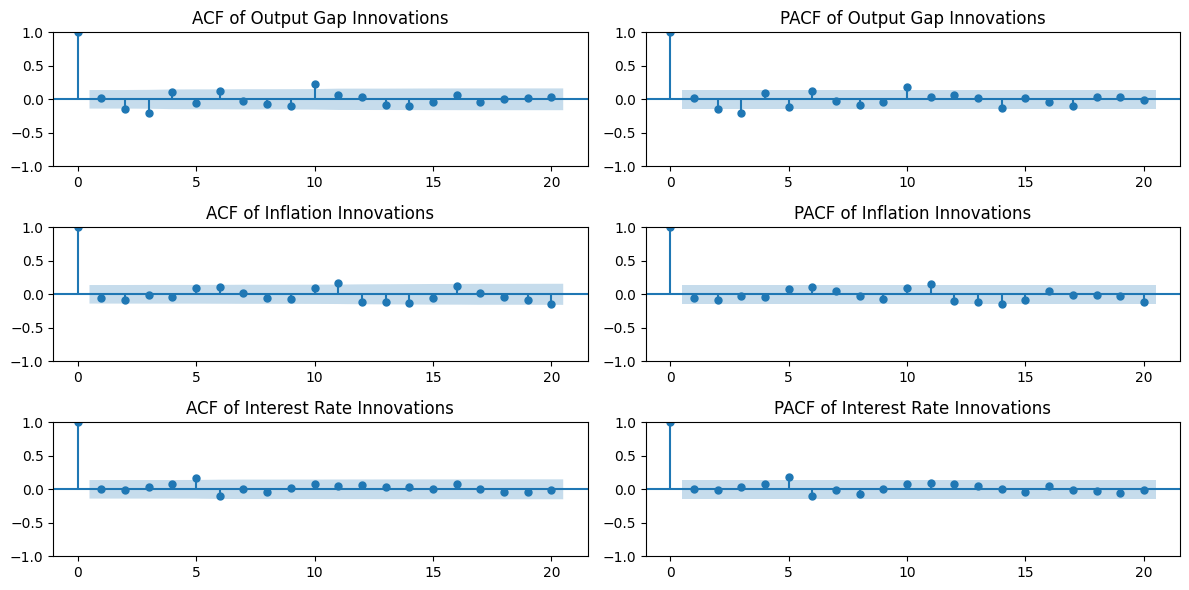

Monte Carlo Ljung-Box summary across 1000 replications:


,measurement,lb_stat,p_value,mc_se_lb_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,OutGap,0.898,0.525,0.041,0.009,1000,42,0.042,0.006,0.031,0.056
1,Infl,0.950,0.519,0.044,0.009,1000,53,0.053,0.007,0.041,0.069
2,Rate,1.078,0.478,0.046,0.009,1000,58,0.058,0.007,0.045,0.074


In [44]:
# Representative ACF/PACF plus Monte Carlo Ljung-Box summary
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov[:, 0], ax=ax[0, 0], lags=20)
plot_pacf(std_innov[:, 0], ax=ax[0, 1], lags=20)
ax[0, 0].set_title("ACF of Output Gap Innovations")
ax[0, 1].set_title("PACF of Output Gap Innovations")

plot_acf(std_innov[:, 1], ax=ax[1, 0], lags=20)
plot_pacf(std_innov[:, 1], ax=ax[1, 1], lags=20)
ax[1, 0].set_title("ACF of Inflation Innovations")
ax[1, 1].set_title("PACF of Inflation Innovations")

plot_acf(std_innov[:, 2], ax=ax[2, 0], lags=20)
plot_pacf(std_innov[:, 2], ax=ax[2, 1], lags=20)
ax[2, 0].set_title("ACF of Interest Rate Innovations")
ax[2, 1].set_title("PACF of Interest Rate Innovations")

plt.tight_layout()
plt.show()

print(f"Monte Carlo Ljung-Box summary across {_MC_SAMPLES} replications:")
mc_reference["lb_summary"].round(3)

In [45]:
print(f"Monte Carlo average of standardized innovation means across {_MC_SAMPLES} replications:\n", mc_reference["moment_mean_vector"].round(3), "\n")
print("Monte Carlo SE of average means:\n", mc_reference["moment_mean_vector_mc_se"].round(3), "\n")
print("Monte Carlo average covariance:\n", mc_reference["moment_covariance"].round(3), "\n")
print("Monte Carlo SE of average covariance:\n", mc_reference["moment_covariance_mc_se"].round(3), "\n")
print("Monte Carlo average correlation:\n", mc_reference["moment_correlation"].round(3), "\n")
print("Monte Carlo SE of average correlation:\n", mc_reference["moment_correlation_mc_se"].round(3), "\n")
print("Max absolute deviations of Monte Carlo average moments:\n", mc_reference["moment_summary"].round(3), "\n")
print("Monte Carlo SE for selected max-deviation components:\n", mc_reference["moment_summary_mc_se"].round(3))

Monte Carlo average of standardized innovation means across 1000 replications:
 OutGap    0.001
Infl     -0.000
Rate      0.003
dtype: float64 

Monte Carlo SE of average means:
 OutGap    0.003
Infl      0.002
Rate      0.002
dtype: float64 

Monte Carlo average covariance:
         OutGap   Infl   Rate
OutGap   3.603 -0.706  0.323
Infl    -0.706  0.565  0.063
Rate     0.323  0.063  0.999 

Monte Carlo SE of average covariance:
         OutGap   Infl   Rate
OutGap   0.011  0.004  0.004
Infl     0.004  0.002  0.002
Rate     0.004  0.002  0.003 

Monte Carlo average correlation:
         OutGap   Infl   Rate
OutGap   1.000 -0.494  0.170
Infl    -0.494  1.000  0.084
Rate     0.170  0.084  1.000 

Monte Carlo SE of average correlation:
         OutGap   Infl   Rate
OutGap   0.000  0.002  0.002
Infl     0.002  0.000  0.002
Rate     0.002  0.002  0.000 

Max absolute deviations of Monte Carlo average moments:
 max_abs_mean                  0.003
max_abs_diag_cov_minus_one    2.603
max_abs_o

In [46]:
mc_reference["moment_specification_test_summary"].round(3)

,test,distance,stat,p_value,mc_se_distance,mc_se_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high,df,sample_size,bandwidth
0,mean_zero_chi2,0.122,3.189,0.496,0.002,0.093,0.009,1000,68,0.068,0.008,0.054,0.085,3.0,200,NaN
1,cov_identity,2.864,36.422,0.000,0.012,0.040,0.000,1000,1000,1.000,0.000,0.996,1.000,6.0,200,4.0


In [47]:
print("Orthogonalization summary (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["orthogonalization_summary"]).round(3)

Orthogonalization summary (Monte Carlo averages and rejection rates):


,target,regressor,coef,std_error,t_stat,p_value,r2,marginal_r2,mc_se_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,mc_se_marginal_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
1,Pi,x,0.153,0.010,14.806,0.000,0.551,0.491,0.001,0.000,0.064,0.000,0.002,0.002,1000,1000,1.000,0.000,0.996,1.000
0,Pi,r,-0.191,0.125,-1.536,0.254,0.551,0.011,0.007,0.001,0.054,0.010,0.002,0.000,1000,413,0.413,0.016,0.383,0.444
3,x,Pi,3.416,0.233,14.806,0.000,0.553,0.490,0.010,0.001,0.064,0.000,0.002,0.002,1000,1000,1.000,0.000,0.996,1.000
2,x,r,-0.617,0.592,-1.041,0.232,0.553,0.014,0.042,0.003,0.073,0.009,0.002,0.001,1000,441,0.441,0.016,0.411,0.472
5,r,Pi,-0.061,0.040,-1.536,0.254,0.088,0.024,0.002,0.000,0.054,0.010,0.002,0.001,1000,413,0.413,0.016,0.383,0.444
4,r,x,-0.008,0.009,-1.041,0.232,0.088,0.028,0.001,0.000,0.073,0.009,0.002,0.001,1000,441,0.441,0.016,0.411,0.472


In [48]:
print("Innovations on orthogonalized predicted states (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["measurement_regressions_orthogonalized_summary"]).round(3)

Innovations on orthogonalized predicted states (Monte Carlo averages and rejection rates):


,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2,mc_se_coef,mc_se_standardized_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,OutGap,Pi,0.360,0.020,1.272,0.278,0.482,0.006,0.041,0.002,0.003,0.032,0.009,0.0,1000,59,0.059,0.007,0.046,0.075
1,OutGap,x,-0.355,-0.089,0.269,-1.273,0.309,0.012,0.009,0.002,0.001,0.030,0.009,0.0,1000,232,0.232,0.013,0.207,0.259
2,OutGap,r,-1.544,-0.047,2.249,-0.666,0.433,0.007,0.074,0.002,0.009,0.032,0.010,0.0,1000,99,0.099,0.009,0.082,0.119
3,Infl,Pi,-0.649,-0.029,1.518,-0.410,0.462,0.006,0.049,0.002,0.003,0.033,0.009,0.0,1000,60,0.060,0.008,0.047,0.076
4,Infl,x,0.033,0.008,0.322,0.114,0.484,0.005,0.011,0.002,0.001,0.033,0.009,0.0,1000,57,0.057,0.007,0.044,0.073
5,Infl,r,-0.325,-0.006,2.688,-0.085,0.488,0.005,0.089,0.002,0.010,0.033,0.009,0.0,1000,59,0.059,0.007,0.046,0.075
6,Rate,Pi,-0.061,-0.015,0.294,-0.208,0.477,0.005,0.010,0.002,0.001,0.033,0.009,0.0,1000,56,0.056,0.007,0.043,0.072
7,Rate,x,0.032,0.034,0.062,0.482,0.458,0.006,0.002,0.002,0.000,0.033,0.010,0.0,1000,74,0.074,0.008,0.059,0.092
8,Rate,r,-0.082,-0.009,0.520,-0.131,0.486,0.005,0.017,0.002,0.002,0.033,0.009,0.0,1000,49,0.049,0.007,0.037,0.064


In [49]:
print("Innovations on raw predicted states (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["measurement_regressions_raw_summary"]).round(3)

Innovations on raw predicted states (Monte Carlo averages and rejection rates):


,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2,mc_se_coef,mc_se_standardized_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
2,OutGap,Pi,-0.646,-0.053,0.846,-0.751,0.438,0.007,0.024,0.002,0.001,0.028,0.009,0.0,1000,92,0.092,0.009,0.076,0.112
1,OutGap,x,-0.246,-0.094,0.178,-1.329,0.280,0.012,0.005,0.002,0.000,0.026,0.008,0.0,1000,216,0.216,0.013,0.192,0.243
0,OutGap,r,-0.774,-0.025,2.148,-0.359,0.513,0.005,0.061,0.002,0.008,0.028,0.009,0.0,1000,43,0.043,0.006,0.032,0.057
5,Infl,Pi,-0.362,-0.024,1.011,-0.340,0.481,0.006,0.032,0.002,0.001,0.032,0.009,0.0,1000,71,0.071,0.008,0.057,0.089
4,Infl,x,-0.043,-0.011,0.214,-0.155,0.495,0.005,0.007,0.002,0.001,0.032,0.009,0.0,1000,59,0.059,0.007,0.046,0.075
3,Infl,r,0.076,0.003,2.563,0.043,0.498,0.005,0.082,0.002,0.009,0.032,0.009,0.0,1000,54,0.054,0.007,0.042,0.070
8,Rate,Pi,0.033,0.011,0.196,0.155,0.505,0.005,0.006,0.002,0.000,0.032,0.009,0.0,1000,54,0.054,0.007,0.042,0.070
7,Rate,x,0.019,0.030,0.041,0.420,0.467,0.006,0.001,0.002,0.000,0.032,0.009,0.0,1000,82,0.082,0.009,0.067,0.101
6,Rate,r,-0.104,-0.012,0.496,-0.170,0.495,0.005,0.016,0.002,0.002,0.032,0.009,0.0,1000,52,0.052,0.007,0.040,0.068


In [50]:
print("Innovations on orthogonalized predicted states, no intercept (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["measurement_regressions_orthogonalized_no_intercept_summary"]).round(3)

Innovations on orthogonalized predicted states, no intercept (Monte Carlo averages and rejection rates):


,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2,mc_se_coef,mc_se_standardized_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,OutGap,Pi,0.360,0.020,1.271,0.278,0.482,0.003,0.041,0.002,0.003,0.032,0.009,0.0,1000,59,0.059,0.007,0.046,0.075
1,OutGap,x,-0.355,-0.089,0.268,-1.275,0.308,0.010,0.009,0.002,0.001,0.030,0.009,0.0,1000,232,0.232,0.013,0.207,0.259
2,OutGap,r,-1.544,-0.047,2.247,-0.666,0.433,0.005,0.074,0.002,0.009,0.032,0.010,0.0,1000,98,0.098,0.009,0.081,0.118
3,Infl,Pi,-0.649,-0.029,1.518,-0.410,0.462,0.001,0.049,0.002,0.003,0.033,0.009,0.0,1000,60,0.060,0.008,0.047,0.076
4,Infl,x,0.033,0.008,0.322,0.114,0.484,0.000,0.011,0.002,0.001,0.033,0.009,0.0,1000,56,0.056,0.007,0.043,0.072
5,Infl,r,-0.325,-0.006,2.688,-0.085,0.488,0.000,0.089,0.002,0.010,0.033,0.009,0.0,1000,59,0.059,0.007,0.046,0.075
6,Rate,Pi,-0.061,-0.015,0.294,-0.208,0.477,0.000,0.010,0.002,0.001,0.033,0.009,0.0,1000,56,0.056,0.007,0.043,0.072
7,Rate,x,0.032,0.034,0.062,0.482,0.458,0.001,0.002,0.002,0.000,0.033,0.010,0.0,1000,74,0.074,0.008,0.059,0.092
8,Rate,r,-0.082,-0.009,0.520,-0.131,0.486,0.000,0.017,0.002,0.002,0.033,0.009,0.0,1000,50,0.050,0.007,0.038,0.065


In [51]:
print("Innovations on raw predicted states, no intercept (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["measurement_regressions_raw_no_intercept_summary"]).round(3)

Innovations on raw predicted states, no intercept (Monte Carlo averages and rejection rates):


,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2,mc_se_coef,mc_se_standardized_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
2,OutGap,Pi,-0.597,-0.049,0.842,-0.696,0.453,0.004,0.024,0.002,0.001,0.028,0.009,0.0,1000,83,0.083,0.009,0.067,0.102
1,OutGap,x,-0.217,-0.082,0.175,-1.187,0.328,0.008,0.005,0.002,0.000,0.027,0.009,0.0,1000,176,0.176,0.012,0.154,0.201
0,OutGap,r,-0.693,-0.023,2.090,-0.329,0.521,0.002,0.059,0.002,0.008,0.028,0.009,0.0,1000,40,0.040,0.006,0.030,0.054
5,Infl,Pi,-0.272,-0.018,1.007,-0.251,0.490,0.000,0.032,0.002,0.001,0.032,0.009,0.0,1000,59,0.059,0.007,0.046,0.075
4,Infl,x,-0.022,-0.004,0.210,-0.059,0.504,0.000,0.007,0.002,0.001,0.033,0.009,0.0,1000,62,0.062,0.008,0.049,0.079
3,Infl,r,0.248,0.008,2.496,0.114,0.496,0.000,0.081,0.002,0.009,0.033,0.009,0.0,1000,55,0.055,0.007,0.042,0.071
8,Rate,Pi,0.018,0.006,0.195,0.082,0.504,0.000,0.006,0.002,0.000,0.032,0.009,0.0,1000,54,0.054,0.007,0.042,0.070
7,Rate,x,0.015,0.022,0.041,0.318,0.482,0.001,0.001,0.002,0.000,0.032,0.009,0.0,1000,72,0.072,0.008,0.058,0.090
6,Rate,r,-0.057,-0.005,0.483,-0.076,0.496,0.000,0.016,0.002,0.002,0.032,0.009,0.0,1000,50,0.050,0.007,0.038,0.065


Monte Carlo summaries above aggregate `_MC_SAMPLES` independent draws. The plots and MCMC output below continue on a representative first draw so the original visual workflow remains available.


In [52]:
parser_aug = ModelParser(_AUGMENTED_CONFIG)
config_aug, kalman_aug = parser_aug.get_all()
solver_aug = DSGESolver(config_aug, kalman_aug)
comp_aug = solver_aug.compile(
    n_state=3,
    n_exog=3,
)
priors = {
    _AUGMENTED_PARAM: make_prior(
        'normal',
        parameters={"mean": 0.0, "std": 4.0, "random_state": next_seed(_plot_seed_counter)},
        transform="identity",
    ),
}

with STDOUT_VOID():
    mc_aug = summarize_mle_augmentation_experiment(
        sol,
        solver_aug,
        comp_aug,
        sol_dgp,
        mc_reference,
        T=T,
        candidate_param=_AUGMENTED_PARAM,
        mc_samples=_MC_SAMPLES,
        alpha=_MC_ALPHA,
    )

estim = lambda: solver_aug.estimate_and_solve(
    compiled=comp_aug,
    method="mcmc",
    n_draws=25_000,
    burn_in=10_000,
    thin=2,
    posterior_point="mean",
    proposal_scale=1.0,
    y=obs,
    priors=priors,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    random_state=next_seed(_plot_seed_counter),
    **mc_reference["filter_kwargs"],
)
res_aug, sol_aug = estim()


MCMC sampling concluded in 168.98 seconds with 355.08 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


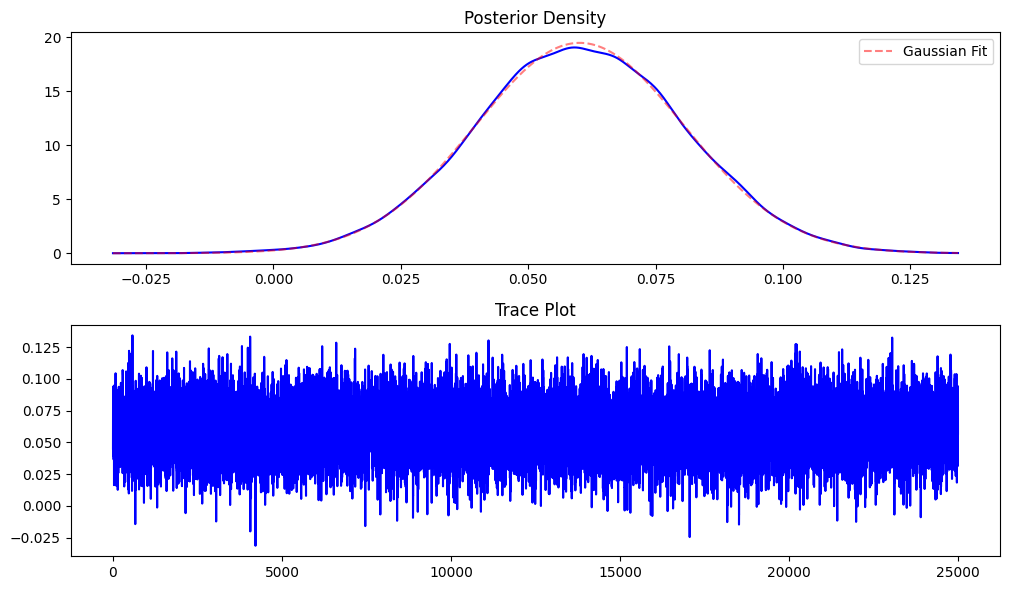

In [53]:
coeff_trace = res_aug.samples[:, 0]

kde = gaussian_kde(coeff_trace)
norm_fit = norm(loc=coeff_trace.mean(), scale=coeff_trace.std())
x_range = np.linspace(coeff_trace.min(), coeff_trace.max(), 1000)
fig, ax = plt.subplots(2, 1, figsize=_FIGSIZE_1D)

ax[0].plot(x_range, kde(x_range), color="blue")
ax[0].plot(x_range, norm_fit.pdf(x_range), linestyle="--", color="red", alpha=0.5, label="Gaussian Fit")
ax[0].set_title("Posterior Density")
ax[0].legend()

ax[1].plot(coeff_trace, color="blue")
ax[1].set_title("Trace Plot")

plt.tight_layout()
plt.show()

In [54]:
sol_aug.config.calibration.parameters[_AUGMENTED_PARAM].round(3)

np.float64(0.06)

In [55]:
tuple(map(lambda x: float(x.round(3)), res_aug.hpd_intervals()[_AUGMENTED_PARAM]))

(0.02, 0.1)

In [56]:
res_aug.accept_rate

np.float64(0.44356666666666666)

The MCMC estimates above are shown for the representative first draw. The Monte Carlo summaries for correction tests below are computed with MLE to keep the replicated stage tractable.


In [57]:
kf_aug = sol_aug.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
    **mc_reference["filter_kwargs"],
)
round(kf_aug.loglik, 2)

-1228.72

## Diagnostics of the Augmented Model

The figures below still display the representative first draw. The scalar summaries reported in later cells are Monte Carlo averages.


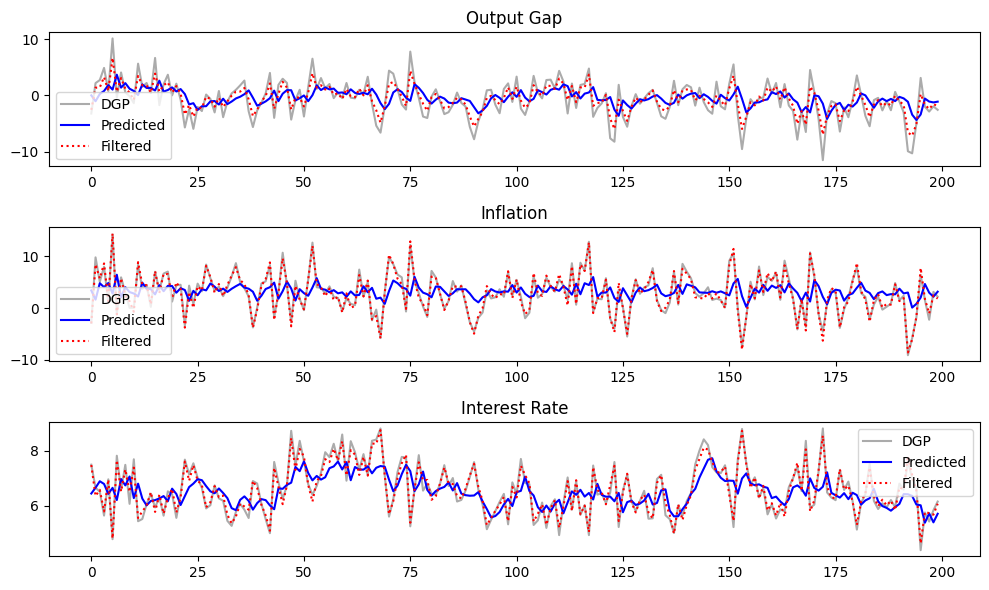

In [58]:
# Plot KF outputs for the representative augmented draw
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)
ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), kf_aug.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf_aug.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), kf_aug.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf_aug.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), kf_aug.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf_aug.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

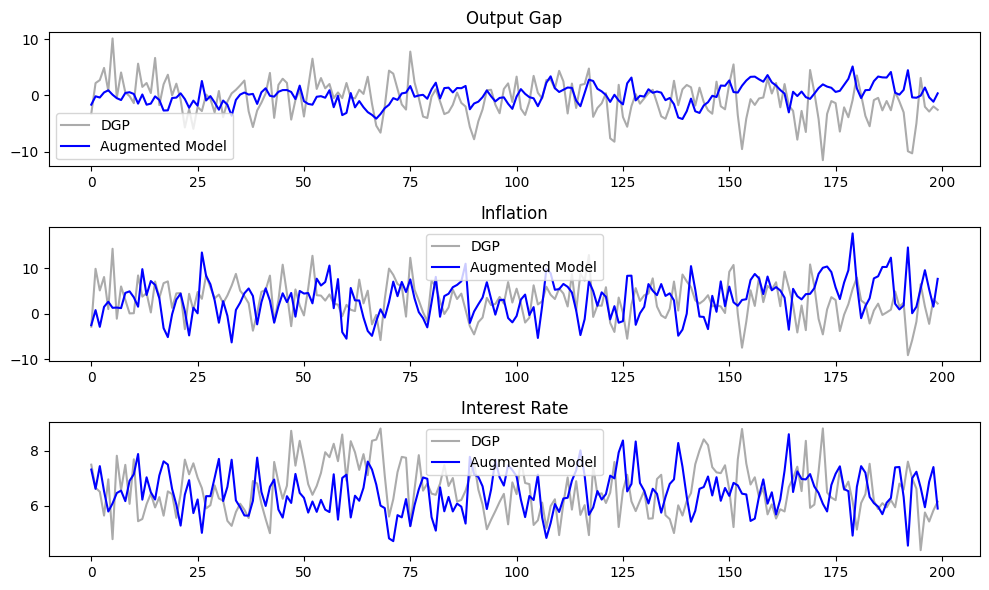

In [59]:
# Simulation against DGP for the representative augmented draw
sim_aug = sol_aug.sim(
    T=T,
    shocks={
        "g,z": Shock(T, "norm", multivar=True, seed=next_seed(_plot_seed_counter)).shock_generator(),
        "r": Shock(T, "norm", multivar=False, seed=next_seed(_plot_seed_counter)).shock_generator(),
    },
    observables=True,
)
aug = np.column_stack([sim_aug["OutGap"], sim_aug["Infl"], sim_aug["Rate"]])[1:, :]
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), aug[:, 0], label="Augmented Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), aug[:, 1], label="Augmented Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), aug[:, 2], label="Augmented Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

### Marginal LR Test Conditional on $	heta_0$

The table below reports the Monte Carlo MLE summary for the LR test.


In [61]:
print("Monte Carlo LR summary for the MLE-augmented model:")
rep_aug = mc_aug["representative"]
res_mle = rep_aug.res_mle
sol_mle = rep_aug.sol_mle
mle_aug_kf = rep_aug.kf_aug
std_innov_aug_mle = rep_aug.std_innov_aug
sim_aug_mle = rep_aug.sim_aug
mc_aug["lr_summary"].round(3)

Monte Carlo LR summary for the MLE-augmented model:


,estimated_coef,loglik_ref,loglik_aug,lr,p_value,mc_se_estimated_coef,mc_se_loglik_ref,mc_se_loglik_aug,mc_se_lr,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,0.061,-1294.052,-1288.757,10.589,0.032,0.001,1.244,1.237,0.201,0.003,999,874,0.875,0.01,0.853,0.894


In [62]:
res_mle

OptimizationResult(kind='mle', x=array([0.06829618]), theta={'beta': np.float64(0.971), 'kappa': np.float64(0.58), 'tau_inv': np.float64(1.86), 'psi_pi': np.float64(2.19), 'psi_x': np.float64(0.3), 'rho_r': np.float64(0.84), 'rho_g': np.float64(0.83), 'rho_z': np.float64(0.85), 'pi_star': np.float64(3.43), 'r_star': np.float64(3.01), 'sig_r': np.float64(0.18), 'sig_g': np.float64(0.18), 'sig_z': np.float64(0.64), 'rho_gz': np.float64(0.36), 'meas_infl': np.float64(1e-06), 'meas_rate': np.float64(1e-06), 'meas_outgap': np.float64(1e-06), 'meas_rho_ir': np.float64(0.0), 'meas_rho_gi': np.float64(0.0), 'meas_rho_gr': np.float64(0.0), 'Pi_coef': np.float64(0.0), 'x_coef': np.float64(0.0682961788214334), 'r_coef': np.float64(0.0)}, success=True, message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', fun=np.float64(1286.1560343762985), loglik=np.float64(-1286.1560343762985), logprior=np.float64(0.0), logpost=np.float64(-1286.1560343762985), nfev=10, nit=3, raw=  message: CONVERGENCE

## Serial Autocorrelation Tests for the Augmented Model

The figure below uses the representative MCMC draw, while the printed table reports Monte Carlo MLE rejection frequencies.


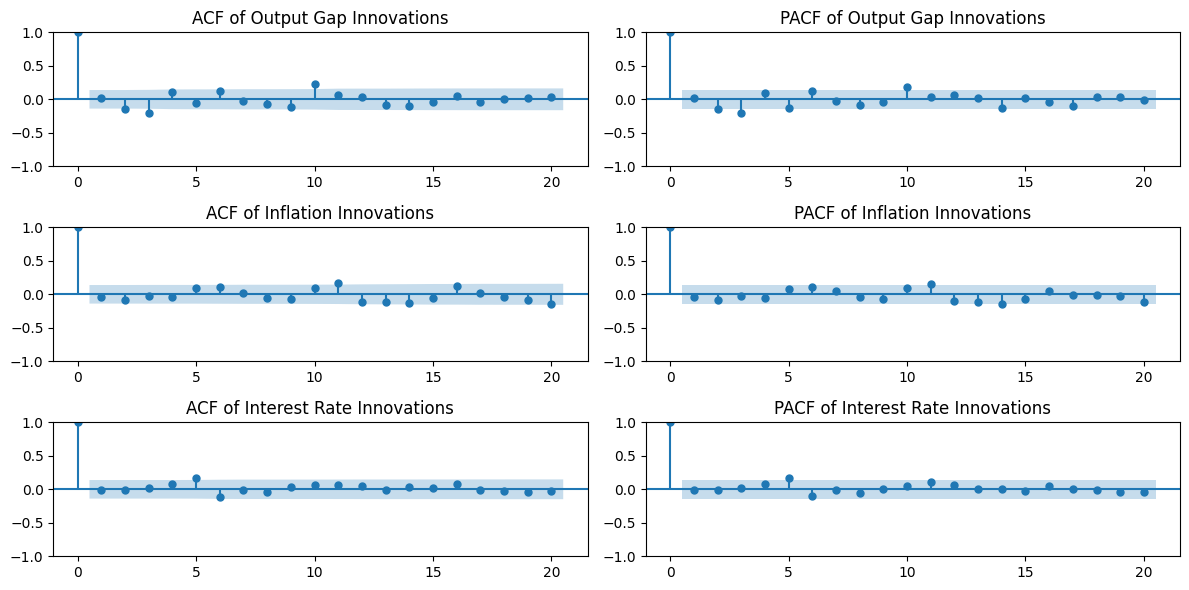

Monte Carlo Ljung-Box summary for the MLE-augmented model:


,measurement,lb_stat,p_value,mc_se_lb_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,OutGap,0.913,0.524,0.042,0.009,999,41,0.041,0.006,0.030,0.055
1,Infl,0.966,0.515,0.045,0.009,999,54,0.054,0.007,0.042,0.070
2,Rate,1.061,0.485,0.046,0.009,999,54,0.054,0.007,0.042,0.070


In [63]:
std_innov_aug = standardize_innovations(kf_aug)

fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov_aug[:, 0], ax=ax[0, 0], lags=20, title="ACF of Output Gap Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 0], ax=ax[0, 1], lags=20, title="PACF of Output Gap Innovations", label="Augmented Model")

plot_acf(std_innov_aug[:, 1], ax=ax[1, 0], lags=20, title="ACF of Inflation Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 1], ax=ax[1, 1], lags=20, title="PACF of Inflation Innovations", label="Augmented Model")

plot_acf(std_innov_aug[:, 2], ax=ax[2, 0], lags=20, title="ACF of Interest Rate Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 2], ax=ax[2, 1], lags=20, title="PACF of Interest Rate Innovations", label="Augmented Model")

plt.tight_layout()
plt.show()

print("Monte Carlo Ljung-Box summary for the MLE-augmented model:")
mc_aug["lb_summary"].round(3)

In [64]:
mu_aug = std_innov_aug.mean(axis=0)
Sigma_aug = np.cov(std_innov_aug, rowvar=False)

print("Representative mean of augmented model innovations:", mu_aug.round(3), "\n")
print("Representative covariance of augmented model innovations:\n", Sigma_aug.round(3), "\n")
print("Monte Carlo average mean vector:\n", mc_aug["moment_mean_vector"].round(3), "\n")
print("Monte Carlo SE of average means:\n", mc_aug["moment_mean_vector_mc_se"].round(3), "\n")
print("Monte Carlo average covariance:\n", mc_aug["moment_covariance"].round(3), "\n")
print("Monte Carlo SE of average covariance:\n", mc_aug["moment_covariance_mc_se"].round(3), "\n")
print("Max absolute deviations of Monte Carlo average moments:\n", mc_aug["moment_summary"].round(3), "\n")
print("Monte Carlo SE for selected max-deviation components:\n", mc_aug["moment_summary_mc_se"].round(3), "\n")

Representative mean of augmented model innovations: [-0.171  0.031  0.045] 

Representative covariance of augmented model innovations:
 [[ 3.047 -0.556 -0.109]
 [-0.556  0.472  0.178]
 [-0.109  0.178  1.018]] 

Monte Carlo average mean vector:
 OutGap    0.001
Infl     -0.000
Rate      0.003
dtype: float64 

Monte Carlo SE of average means:
 OutGap    0.003
Infl      0.002
Rate      0.002
dtype: float64 

Monte Carlo average covariance:
         OutGap   Infl   Rate
OutGap   3.602 -0.707 -0.078
Infl    -0.707  0.566  0.117
Rate    -0.078  0.117  0.986 

Monte Carlo SE of average covariance:
         OutGap   Infl   Rate
OutGap   0.011  0.004  0.001
Infl     0.004  0.002  0.002
Rate     0.001  0.002  0.003 

Max absolute deviations of Monte Carlo average moments:
 max_abs_mean                  0.003
max_abs_diag_cov_minus_one    2.602
max_abs_offdiag_cov           0.707
dtype: float64 

Monte Carlo SE for selected max-deviation components:
 max_abs_mean                  0.002
max_abs_di

In [65]:
print("Reference moment-specification test summary:")
display(mc_reference["moment_specification_test_summary"].round(3))

print("Augmented moment-specification test summary:")
display(mc_aug["moment_specification_test_summary"].round(3))

print("Reference-minus-augmented moment distance comparison:")
display(mc_aug["moment_specification_comparison"].round(3))

Reference moment-specification test summary:


,test,distance,stat,p_value,mc_se_distance,mc_se_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high,df,sample_size,bandwidth
0,mean_zero_chi2,0.122,3.189,0.496,0.002,0.093,0.009,1000,68,0.068,0.008,0.054,0.085,3.0,200,NaN
1,cov_identity,2.864,36.422,0.000,0.012,0.040,0.000,1000,1000,1.000,0.000,0.996,1.000,6.0,200,4.0


Augmented moment-specification test summary:


,test,distance,stat,p_value,mc_se_distance,mc_se_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high,df,sample_size,bandwidth
0,mean_zero_chi2,0.122,3.138,0.5,0.002,0.091,0.009,999,65,0.065,0.008,0.051,0.082,3.0,200,NaN
1,cov_identity,2.826,36.084,0.0,0.012,0.043,0.000,999,999,1.000,0.000,0.996,1.000,6.0,200,4.0


Reference-minus-augmented moment distance comparison:


,test,n_replications,distance_ref,mc_se_distance_ref,distance_aug,mc_se_distance_aug,distance_improvement,mc_se_distance_improvement,stat_ref,mc_se_stat_ref,stat_aug,mc_se_stat_aug,stat_improvement,mc_se_stat_improvement,aug_closer_rate,aug_closer_rate_mc_se,aug_closer_ci_low,aug_closer_ci_high
0,mean_zero_chi2,999,0.122,0.002,0.122,0.002,0.000,0.000,3.19,0.093,3.138,0.091,0.051,0.008,0.518,0.016,0.487,0.548
1,cov_identity,999,2.865,0.012,2.826,0.012,0.039,0.001,36.42,0.040,36.084,0.043,0.335,0.008,0.917,0.009,0.898,0.932


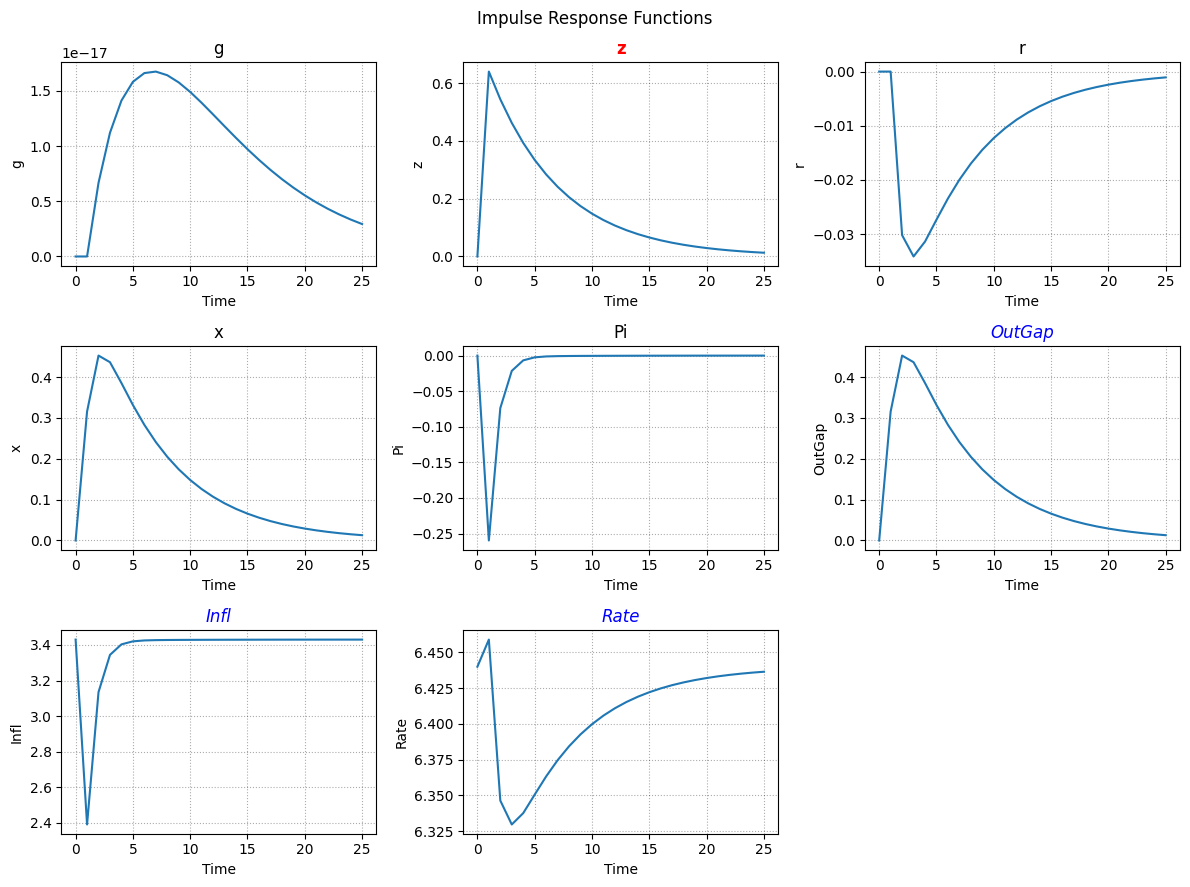

In [66]:
sol_aug.transition_plot(
    T=25,
    observables=True,
    shocks=["z"],
    scale=1.0,
)